In [1]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Dataset extracted!")

Dataset extracted!


In [2]:
import os

print(os.listdir())

['.config', 'archive.zip', 'credit_card_fraud_10k.csv', 'sample_data']


In [3]:
import pandas as pd

df = pd.read_csv("credit_card_fraud_10k.csv")

df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
print(df.shape)

(10000, 10)


In [5]:
df["is_fraud"].value_counts()

,count
is_fraud,
0,9849
1,151


In [6]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["merchant_category"].value_counts()

,count
merchant_category,
Food,2093
Clothing,2050
Travel,1990
Grocery,1944
Electronics,1923


In [9]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (10000, 9)
Target: (10000,)


In [10]:
X = pd.get_dummies(
    X.drop("transaction_id", axis=1),
    columns=["merchant_category"],
    drop_first=True
)

print("New feature shape:", X.shape)

New feature shape: (10000, 11)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 11)
Testing data: (2000, 11)


In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [13]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9915


In [15]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Fraud"]
))

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1970
       Fraud       1.00      0.43      0.60        30

    accuracy                           0.99      2000
   macro avg       1.00      0.72      0.80      2000
weighted avg       0.99      0.99      0.99      2000



[[1970    0]
 [  17   13]]


NameError: name 'plt' is not defined

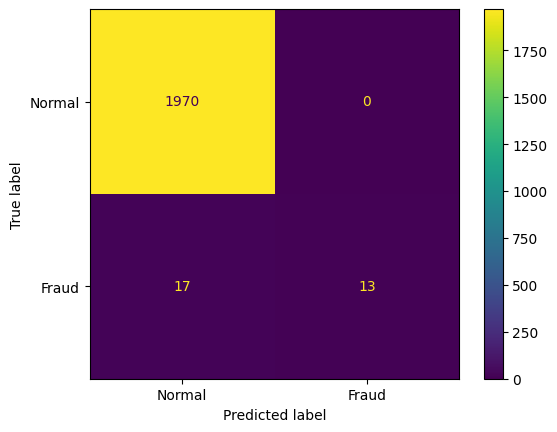

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

disp.plot()
plt.show()

In [17]:
import matplotlib.pyplot as plt

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

device_trust_score               0.256244
transaction_hour                 0.235398
velocity_last_24h                0.142614
foreign_transaction              0.139189
location_mismatch                0.122886
amount                           0.049793
cardholder_age                   0.031898
merchant_category_Travel         0.006979
merchant_category_Electronics    0.006361
merchant_category_Grocery        0.004667
merchant_category_Food           0.003971
dtype: float64


In [19]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [20]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    lr_pred,
    target_names=["Normal", "Fraud"]
))

              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98      1970
       Fraud       0.26      0.97      0.41        30

    accuracy                           0.96      2000
   macro avg       0.63      0.96      0.69      2000
weighted avg       0.99      0.96      0.97      2000



[[1886   84]
 [   1   29]]


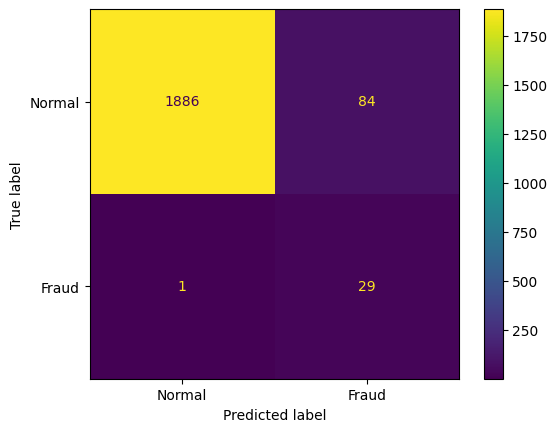

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lr = confusion_matrix(y_test, lr_pred)

print(cm_lr)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Normal", "Fraud"]
)

disp_lr.plot()
plt.show()

In [22]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [0.9915, 0.96],
    "Fraud Precision": [1.00, 0.26],
    "Fraud Recall": [0.43, 0.97],
    "Fraud F1": [0.60, 0.41]
})

comparison

,Model,Accuracy,Fraud Precision,Fraud Recall,Fraud F1
0,Random Forest,0.9915,1.00,0.43,0.60
1,Logistic Regression,0.9600,0.26,0.97,0.41


In [23]:
# Test a new transaction

new_transaction = pd.DataFrame({
    "amount": [5000],
    "transaction_hour": [2],
    "merchant_category": ["Electronics"],
    "foreign_transaction": [1],
    "location_mismatch": [1],
    "device_trust_score": [20],
    "velocity_last_24h": [10],
    "cardholder_age": [30]
})

new_transaction = pd.get_dummies(
    new_transaction,
    columns=["merchant_category"],
    drop_first=True
)

new_transaction = new_transaction.reindex(columns=X.columns, fill_value=0)

prediction = model.predict(new_transaction)

if prediction[0] == 1:
    print("🚨 Fraudulent Transaction")
else:
    print("✅ Normal Transaction")

🚨 Fraudulent Transaction


In [24]:
normal_transaction = pd.DataFrame({
    "amount": [200],
    "transaction_hour": [14],
    "merchant_category": ["Grocery"],
    "foreign_transaction": [0],
    "location_mismatch": [0],
    "device_trust_score": [90],
    "velocity_last_24h": [1],
    "cardholder_age": [35]
})

normal_transaction = pd.get_dummies(
    normal_transaction,
    columns=["merchant_category"],
    drop_first=True
)

normal_transaction = normal_transaction.reindex(
    columns=X.columns,
    fill_value=0
)

prediction = model.predict(normal_transaction)

if prediction[0] == 1:
    print("🚨 Fraudulent Transaction")
else:
    print("✅ Normal Transaction")

✅ Normal Transaction
